In [ ]:
from IPython import get_ipython
from IPython.display import display
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install libraries to use GPU acceleration for our model.

In [ ]:
!apt-get update -y
!apt-get install -y pciutils lshw
!apt update && apt install -y lsof net-tools

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [5,988 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,532 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRel

Depending on the chosen model, adapt the code

In [ ]:
from pathlib import Path
import os, time, math
from openai import OpenAI
from typing import List
from google.colab import files, userdata

In [ ]:
model_name   = "gpt-5-mini"   # ← Adapt if needed
TEMPERATURE = 1

In [ ]:
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY') or os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("Aucune clé OPENAI_API_KEY. Dans Colab: Secrets ▸ ajouter OPENAI_API_KEY.")
client = OpenAI(api_key=OPENAI_API_KEY)

# Sanity check (laisse tes hyperparamètres inchangés ailleurs)
_ = client.chat.completions.create(
    model=model_name,
    messages=[{"role":"system","content":"You are a helpful assistant."},
              {"role":"user","content":"Hello, how are you today?"}]
)

print(_)

ChatCompletion(id='chatcmpl-CdEvDi6EevJHXORqIrXKuWbNxreG8', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="I'm doing well, thanks — ready to help. How are you, and what can I do for you today?", refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1763468187, model='gpt-5-mini-2025-08-07', object='chat.completion', service_tier='default', system_fingerprint=None, usage=CompletionUsage(completion_tokens=32, prompt_tokens=23, total_tokens=55, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))


Avant de commencer nous allons installer l'ensemble des librairies necessaires au fonctionnement de notre code.

In [ ]:
!pip install ocrmypdf PyPDF2 pdf2image pytesseract
!pip install pikepdf
!apt-get update -qq
!apt-get install -y -qq ghostscript tesseract-ocr
!pip install -q ocrmypdf
!pip install PyPDF2 langdetect
!apt-get update -qq
!apt-get install -y -qq unpaper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.9 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-droid-fallback.
(Reading database ... 121736 files and directories currently installed.)
Preparing to unpack .../0-fonts-droid-fallback_1%3a6.0.1r16-1.1build1_all.deb ...
Unpacking fonts-droid-fallback (1:6.0.1r16-1.1build1) ...
Selecting previously unselected package poppler-data.
Preparing to

In [ ]:
import os
import re
from PyPDF2 import PdfWriter
from PyPDF2 import PdfReader
import ocrmypdf
import langdetect
from langdetect import detect_langs, LangDetectException
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
import pandas as pd
import json
import shutil
from tempfile import template
import unicodedata
import pikepdf
import logging
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import textwrap
import logging

We can now begin our thematic analysis.
To do this, we will apply a prompt to each text and retrieve the responses in an Excel file.
 Then, we will take all these themes and apply a new analysis to arrive at major similar themes between actors and then indicate it in our Excel file.

 We will do this for each of the national languages present in the opinions, namely Italian, German, and French.
Once this is done, we will group our themes and translate them all into French.

In [ ]:

OPENAI_API_KEY = userdata.get('OPENAI_API_KEY') or os.getenv("OPENAI_API_KEY")

base_dir = Path('/content/drive/MyDrive/Consulation_NLP_imp')
roots = {
    "FR": base_dir / "Extracted_French",
    "DE": base_dir / "Extracted_German",
    "IT": base_dir / "Extracted_Italian",
}
output_excel = base_dir / "openai_outputs_with_thematics.xlsx"

# -------- PROMPTS (unchanged) --------
templates = {
    "FR": {
        "resume": (
            "Tu es un haut-fonctionnaire qui est mandaté pour produire un rapport de résultat "
            "sur un processus de consultation sur"
            " une réforme du code pénal. "
            "Veuillez produire un résumé clair et synthétique du document ci-dessous, "
            "en restituant fidèlement les idées principales et la progression argumentative :\n\n"
            "{texte}\n\n"
            "**Réponds** sans en-tête, sans guillemets, sans autre texte."
        ),
        "themes": (
            "Tu es un chercheur en sciences sociales, spécialiste en analyse thématique QUALITATIVE. "
            "À partir du texte fourni ci-dessous, réalise une **analyse thématique interprétative** "
            "en identifiant les **thématiques latentes** (valeurs, préoccupations, représentations) "
            "exprimées par l’acteur dans la procédure de consultation sur la réforme"
            "du code pénal \n\n"
            "Consignes strictes :\n"
            "- Donne uniquement une liste à puces.\n"
            "- Formule chaque thématique de façon concise (2 à 4 mots), au niveau interprétatif "
            "(valeurs/principes), et non contextuel.\n"
            "- Classe-les par ordre décroissant d’importance (poids discursif).\n"
            "- Ne donne ni titre, ni guillemets, ni texte explicatif.\n"
            "Texte à analyser :\n"
            "{texte}\n\n"
            "Thématiques latentes :"
        ),
    },
    "DE": {
        "resume": (
            "Du bist ein hoher Beamter, beauftragt, einen Ergebnisbericht über ein Konsultationsverfahren "
            "zur Reform des Strafgesetzbuches zu erstellen. Bitte erstelle eine klare und prägnante "
            "Zusammenfassung des untenstehenden Dokuments, die die Hauptgedanken und den "
            "Argumentationsverlauf originalgetreu wiedergibt:\n\n"
            "{texte}\n\n"
            "**Antworte** ohne Überschrift, ohne Anführungszeichen, ohne weiteren Text."
        ),
        "themes": (
            "Du bist ein Sozialwissenschaftler mit Spezialisierung auf QUALITATIVE thematische Analyse. "
            "Aus dem untenstehenden Text führe eine interpretative thematische Analyse durch, indem du "
            "die latenten Themen (Werte, Anliegen, Repräsentationen) identifizierst, die der Akteur im "
            "Konsultationsverfahren zur Reform des Strafgesetzbuches äußert.\n\n"
            "Strikte Anweisungen:\n"
            "- Gib ausschließlich eine Liste mit Aufzählungszeichen.\n"
            "- Formuliere jedes Thema prägnant (2–4 Wörter) auf interpretativer Ebene (Werte/Prinzipien), nicht kontextuell.\n"
            "- Ordne sie nach absteigender Wichtigkeit (diskursives Gewicht).\n"
            "- Gib weder Titel noch Anführungszeichen noch erklärenden Text.\n\n"
            "Zu analysierender Text:\n"
            "{texte}\n\n"
            "Latente Themen:"
        ),
    },
    "IT": {
        "resume": (
            "Sei un alto funzionario incaricato di redigere un rapporto sui risultati di un processo di consultazione "
            "sulla riforma del codice penale. Genera un riassunto chiaro e sintetico del documento seguente, "
            "restituendo fedelmente le idee principali e il percorso argomentativo:\n\n"
            "{texte}\n\n"
            "**Rispondi** senza intestazione, senza virgolette, senza altro testo."
        ),
        "themes": (
            "Sei un ricercatore in scienze sociali, specialista in analisi tematica QUALITATIVA. "
            "A partire dal testo fornito di seguito, esegui un'analisi tematica interpretativa identificando "
            "i temi latenti (valori, preoccupazioni, rappresentazioni) espressi dall’attore nella procedura "
            "di consultazione sulla riforma del codice penale.\n\n"
            "Istruzioni rigorose:\n"
            "- Fornisci esclusivamente un elenco puntato.\n"
            "- Formula ogni tema in modo conciso (2–4 parole) a livello interpretativo (valori/principi), non contestuale.\n"
            "- Ordinali in ordine decrescente di importanza (peso discorsivo).\n"
            "- Non includere titoli, virgolette o testi esplicativi.\n\n"
            "Testo da analizzare:\n"
            "{texte}\n\n"
            "Temi latenti:"
        ),
    },
}


# -------- MAIN --------
results = []
for lang, folder in roots.items():
    if not folder.exists():
        print(f"⚠️ Folder not found for {lang}: {folder}")
        continue
    tpl = templates[lang]
    for pdf_path in folder.rglob("*.pdf"):
        reader = PdfReader(str(pdf_path))
        full_text = "\n".join(page.extract_text() or "" for page in reader.pages)

        # --- Step 1: summary ---
        prompt_sum = tpl["resume"].format(texte=full_text)
        print("\n=== SUMMARY PROMPT ===\n", prompt_sum)

        try:
            response_sum = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": prompt_sum}],
                temperature=TEMPERATURE
            )
            summary = response_sum.choices[0].message.content.strip()
        except Exception as e:
            print(f"⚠️ Summary failed ({lang}) for {pdf_path.name}: {e}")
            summary = ""

        print("=== SUMMARY OUTPUT ===\n", summary)

        # --- Step 2: thematics ---
        prompt_them = tpl["themes"].format(texte=full_text)
        print("\n=== THEMATICS PROMPT ===\n", prompt_them)

        try:
            response_them = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": prompt_them}],
                temperature=1
            )
            thematics = response_them.choices[0].message.content.strip()
        except Exception as e:
            print(f"⚠️ Thematics failed ({lang}) for {pdf_path.name}: {e}")
            thematics = ""

        print("=== THEMATICS OUTPUT ===\n", thematics)

        results.append({
            "lang": lang,
            "filename": pdf_path.name,
            "summary": summary,
            "thematics": thematics
        })

df = pd.DataFrame(results)
df.to_excel(output_excel, index=False)
print("✅ Results saved to:", output_excel)
print(df.head())

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.


**Antworte** ohne Überschrift, ohne Anführungszeichen, ohne weiteren Text.
=== SUMMARY OUTPUT ===
 Die Standeskommission des Kantons Appenzell Innerrhoden lehnt den Vorentwurf zur Änderung des Strafgesetzbuchs und des Militärstrafgesetzes im Zusammenhang mit der parlamentarischen Initiative 19.300 ab. Sie weist darauf hin, dass nach heutigem Recht Mord nach 30 Jahren verjährt, während Art. 101 StGB bestimmte schwerste Delikte (Völkermord, Verbrechen gegen die Menschlichkeit, besonders schwere Terrorakte bzw. Kriegsverbrechen und sexuelle Gewalt gegenüber Kindern, Vergewaltigung, Nötigung etc.) von der Verjährung ausnimmt. Diese Regelung zeige, dass außerhalb der in lit. d genannten Sexualdelikte vorwiegend Kriegs- und Terrorverbrechen unverjährbar seien; bei lit. d sei zudem die anhaltende und oft verdrängte Wirkung auf Opfer zu berücksichtigen. Die Kommission betont, dass Mord andere Voraussetzungen habe: 

Now we will translate the themes of the different opinions so that we can process them together later.

In [ ]:
# 1) Paths
base_dir     = Path('/content/drive/MyDrive/Consulation_NLP_imp')
input_excel  = base_dir / "openai_outputs_with_thematics.xlsx"
output_excel = base_dir / "openai_outputs_with_thematics.xlsx"

# 2) Load the Excel
df = pd.read_excel(input_excel)
print("➡️ Available columns:", df.columns.tolist())

# 3) Translation template
translate_template = (
    "Veuillez traduire en français la liste de thèmes suivante, "
    "en conservant la structure en liste à puces si présente, "
    "et en veillant à ce que le contenu soit clair et précis :\n\n"
    "{thematics}\n\n"
    "**Réponds** sans en-tête, sans guillemets, sans autre texte."
    "Thèmes en français :"
)

# 4) Translation function
def translate_thematics(text):
    if not text.strip():
        return ""  # nothing to translate

    prompt = translate_template.format(thematics=text)

    # Display the prompt
    print("\n=== PROMPT SENT ===")
    print(prompt)

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE
        )
        result = response.choices[0].message.content.strip()
        print("=== MODEL RESPONSE ===")
        print(result)
        return result

    except Exception as e:
        print(f"⚠️ Failure for «{text[:30]}…»\n{e}")
        return ""

# 5) Apply the translation
df['thematics_fr'] = df['thematics'].astype(str).apply(translate_thematics)

# 6) Save
df.to_excel(output_excel, index=False)
print("✅ Translated columns added and file saved to:", output_excel)


➡️ Available columns: ['lang', 'filename', 'summary', 'thematics']

=== PROMPT SENT ===
Veuillez traduire en français la liste de thèmes suivante, en conservant la structure en liste à puces si présente, et en veillant à ce que le contenu soit clair et précis :

- Prévention des erreurs judiciaires
- Fiabilité des preuves
- Procès équitable
- Sécurité juridique
- Protection des droits individuels
- Proportionnalité des sanctions
- Prudence réformatrice
- Adaptation au progrès scientifique
- Cohérence législative
- Réflexion politique globale

**Réponds** sans en-tête, sans guillemets, sans autre texte.Thèmes en français :
=== MODEL RESPONSE ===
- Prévention des erreurs judiciaires
- Fiabilité des preuves
- Procès équitable
- Sécurité juridique
- Protection des droits individuels
- Proportionnalité des sanctions
- Prudence réformatrice
- Adaptation au progrès scientifique
- Cohérence législative
- Réflexion politique globale

=== PROMPT SENT ===
Veuillez traduire en français la liste de

In [ ]:
# 1) Paths & parameters
base_dir    = Path('/content/drive/MyDrive/Consulation_NLP_imp')
input_file  = base_dir / "openai_outputs_with_thematics.xlsx"
col_name    = "thematics_fr"

# 2) Load the DataFrame
df = pd.read_excel(input_file)

# 3) Build and display the prompt
texts    = df[col_name].dropna().astype(str).tolist()
numbered = "\n".join(f"{i+1}. {t}" for i,t in enumerate(texts,1))
prompt   = f"""\
Tu es un chercheur en sciences sociales, spécialiste en analyse thématique qualitative.
Voici la liste complète des thématique extraits de la colonne « {col_name} » :
{numbered}

Effectue un regroupement en exactement 5 catégories thématiques représentatives et distinguables.
**Réponds** sans en-tête, sans guillemets, sous la forme :
<catégorie> : description de la catégorie
"""
print("=== PROMPT SENT ===\n", prompt)

#call chatgpt
try:
    response_obj = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": prompt}],
        temperature=TEMPERATURE
    )
    response = response_obj.choices[0].message.content.strip()

except Exception as e:
    raise RuntimeError(f"OpenAI API error:\n{e}")

print("=== MODEL RESPONSE ===\n", response)

# 5) Delete the old column if it exists
if 'general_theme_codebook' in df.columns:
    df = df.drop(columns=['general_theme_codebook'])

# 6) Insert the new column just after 'thematics_fr'
insert_at = df.columns.get_loc(col_name) + 1
df.insert(insert_at, 'general_theme_codebook', "")

# 7) Place the model's response in the first cell below the header
df.iat[0, insert_at] = response

# 8) Save
df.to_excel(input_file, index=False)
print("✅ Column 'general_theme_codebook' added, response inserted in row 1.")

=== PROMPT SENT ===
 Tu es un chercheur en sciences sociales, spécialiste en analyse thématique qualitative.
Voici la liste complète des thématique extraits de la colonne « thematics_fr » :
2. - Prévention des erreurs judiciaires
- Fiabilité des preuves
- Procès équitable
- Sécurité juridique
- Protection des droits individuels
- Proportionnalité des sanctions
- Prudence réformatrice
- Adaptation au progrès scientifique
- Cohérence législative
- Réflexion politique globale
3. - Cohérence juridique
- Proportionnalité des peines
- Équité procédurale
- Fiabilité des preuves
- Prévention des erreurs judiciaires
- Égalité devant la loi pénale
- Sécurité juridique
- Responsabilité proportionnée
- Prudence législative
- Protection des victimes
4. - Responsabilité pénale permanente
- Justice pour les victimes
- Condamnation morale des crimes
- Primauté de l'État de droit
- Cohérence législative nationale
- Respect des institutions
- Protection de l'ordre public
- Légitimité pénale de l'État
5.

We separate the themes from their descriptions into a new column


In [ ]:

def extract_themes(cell):
    # Convert to string and split on all types of line breaks
    lines = re.split(r'[\r\n]+', str(cell))
    themes = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if ':' in line:
            theme, _ = line.split(':', 1)
            themes.append(theme.strip())
        else:
            # Case where there is no ":"
            themes.append(line)
    return themes

# 3) Apply and create a list column
df['general_theme_fr'] = df['general_theme_codebook'].apply(extract_themes)
df["general_theme_fr"] = df["general_theme_fr"].apply(lambda lst: "\n".join(lst))

# 4) Save back to Excel
df.to_excel(input_file, index=False)

To avoid any hallucination problem of our model, we add the neutral category in our cell of general themes.

In [ ]:
ancienne_valeur = df.at[0, "general_theme_codebook"]
if pd.isna(ancienne_valeur):
    ancienne_valeur = ""


df.at[0, "general_theme_fr"] = f"{ancienne_valeur} \\nAucun de ces thèmes: le document ne correspond a aucun des autres thèmes mentionnés"
df.to_excel(input_file, index=False)

To translate the general themes into German and Italian so that they can be applied to the texts later.

In [ ]:

col_name = "general_theme_fr"

df = pd.read_excel(input_excel)

translate_template = (
    "Bitte übersetzen Sie die folgende Themenliste ins Deutsche, "
    "unter Beibehaltung der Aufzählungsstruktur, falls vorhanden, "
    "und achten Sie darauf, dass der Inhalt klar und präzise ist:\n\n"
    "{thematics}\n\n"
    "**beantworte** ohne Überschrift, ohne Anführungszeichen, ohne weiteren Text. "
    "Themen auf Deutsch:"
)


def translate_thematics(general_theme_fr):
    if not general_theme_fr.strip():
        return ""

    prompt = translate_template.format(thematics=general_theme_fr)
    print("\n=== PROMPT ENVOYÉ ===")
    print(prompt)

    # --- REPLACEMENT OF OLLAMA CALL ---
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE
        )
        response = response_obj.choices[0].message.content.strip()

    except Exception as e:
        print(f"⚠️ Échec pour «{general_theme_fr[:30]}…» : {e}")
        return ""
    # ----------------------------------

    print("=== RÉPONSE DU MODÈLE ===")
    print(response)
    return response


translated = df[col_name].fillna("").astype(str).apply(translate_thematics)

if 'general_theme_de' in df.columns:
    df = df.drop(columns=['general_theme_de'])

insert_at = df.columns.get_loc(col_name) + 1
df.insert(insert_at, 'general_theme_de', translated)

df.to_excel(output_excel, index=False)
print(f"✅ Colonne 'general_theme_de' ajoutée, réponses enregistrées dans {output_excel}")



=== PROMPT ENVOYÉ ===
Bitte übersetzen Sie die folgende Themenliste ins Deutsche, unter Beibehaltung der Aufzählungsstruktur, falls vorhanden, und achten Sie darauf, dass der Inhalt klar und präzise ist:

Preuves et expertise médico-légale : regroupe les interrogations sur la fiabilité, les limites et la temporalité des éléments de preuve (fragilité des preuves médico‑légales, besoin de validation empirique, corroboration, indépendance des experts, conservation des preuves, scepticisme technologique), ainsi que les pratiques d’enquête nécessaires pour garantir l’intégrité probatoire et prévenir les erreurs judiciaires.

Garanties procédurales et État de droit : recouvre les principes procéduraux fondamentaux (présomption d’innocence, procès équitable, non‑rétroactivité, égalité devant la loi, neutralité judiciaire et institutionnelle, séparation des pouvoirs), la sécurité juridique et la protection des droits des personnes accusées contre les erreurs et les atteintes arbitraires.

Tem

In [ ]:

col_name = "general_theme_fr"


translate_template = (
    "Traduci il seguente elenco di temi in italiano, "
    "mantenendo la struttura dell'elenco puntato, se presente, "
    "e assicurandoti che il contenuto sia chiaro e preciso:\n\n"
    "{thematics}\n\n"
    "**rispondi** senza titoli, senza virgolette, senza altro testo aggiuntivo. "
    "Temi in italiano:"
)


def translate_thematics(general_theme_fr):
    if not general_theme_fr.strip():
        return ""

    prompt = translate_template.format(thematics=general_theme_fr)
    print("\n=== PROMPT ENVOYÉ ===")
    print(prompt)

    # --- REPLACE OLLAMA BY OPENAI CHAT COMPLETIONS ---
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE   # <-- uses your global setting
        )
        response = response_obj.choices[0].message.content.strip()

    except Exception as e:
        print(f"⚠️ Échec pour «{general_theme_fr[:30]}…» : {e}")
        return ""
    # -------------------------------------------------

    print("=== RÉPONSE DU MODÈLE ===")
    print(response)
    return response

translated = df[col_name].fillna("").astype(str).apply(translate_thematics)

if 'general_theme_it' in df.columns:
    df = df.drop(columns=['general_theme_it'])
insert_at = df.columns.get_loc(col_name) + 1
df.insert(insert_at, 'general_theme_it', translated)

df.to_excel(output_excel, index=False)
print(f"✅ Colonne 'general_theme_it' ajoutée, réponses enregistrées dans {output_excel}")



=== PROMPT ENVOYÉ ===
Traduci il seguente elenco di temi in italiano, mantenendo la struttura dell'elenco puntato, se presente, e assicurandoti che il contenuto sia chiaro e preciso:

Preuves et expertise médico-légale : regroupe les interrogations sur la fiabilité, les limites et la temporalité des éléments de preuve (fragilité des preuves médico‑légales, besoin de validation empirique, corroboration, indépendance des experts, conservation des preuves, scepticisme technologique), ainsi que les pratiques d’enquête nécessaires pour garantir l’intégrité probatoire et prévenir les erreurs judiciaires.

Garanties procédurales et État de droit : recouvre les principes procéduraux fondamentaux (présomption d’innocence, procès équitable, non‑rétroactivité, égalité devant la loi, neutralité judiciaire et institutionnelle, séparation des pouvoirs), la sécurité juridique et la protection des droits des personnes accusées contre les erreurs et les atteintes arbitraires.

Temporalité des poursuit

In [ ]:

base_dir = Path('/content/drive/MyDrive/Consulation_NLP_imp')
input_excel = base_dir / "openai_outputs_with_thematics.xlsx"
output_excel = input_excel
roots = {
    "FR": base_dir / "Extracted_French",
    "DE": base_dir / "Extracted_German",
    "IT": base_dir / "Extracted_Italian",
}

df = pd.read_excel(input_excel)
general_themes = {}
for lang in ["FR", "DE", "IT"]:
    col = f"general_theme_{lang.lower()}"
    if col not in df.columns:
        raise KeyError(f"Colonne manquante dans Excel: {col}")
    themes = df[col].dropna().unique().tolist()
    general_themes[lang] = ", ".join(themes)

prompt_template = {
    "FR": (
        "Tu es un chercheur en sciences sociales, spécialiste en analyse thématique qualitative.\n"
        "Pour chaque document, indique **uniquement** le thème général correspondant.\n\n"
        "Texte à analyser:\n{texte}\n\n"
        "Thèmes généraux possibles : {general}\n\n"
        "Réponds **exactement** par la seule catégorie choisie (pas de CSV, pas de JSON)."
    ),
    "DE": (
        "Du bist ein Sozialwissenschaftler mit Spezialisierung auf qualitative thematische Analyse.\n"
        "Gib für jedes Dokument **ausschließlich** das zutreffende allgemeine Thema an.\n\n"
        "Zu analysierender Text:\n{texte}\n\n"
        "Mögliche allgemeine Themen : {general}\n\n"
        "Antworte **exakt** mit der ausgewählten Kategorie (kein CSV, kein JSON)."
    ),
    "IT": (
        "Sei un ricercatore in scienze sociali, specialista nell'analisi tematica qualitativa.\n"
        "Per ogni documento, indica **esclusivamente** il tema generale corrispondente.\n\n"
        "Testo da analizzare:\n{texte}\n\n"
        "Possibili temi generali  : {general}\n\n"
        "Rispondi **esattamente** indicando solo la categoria scelta (no CSV, no JSON)."
    )
}

def categorize_document(full_text: str, template: str, general_list: str) -> str:
    prompt = template.format(texte=full_text, general=general_list)
    print("\n=== PROMPT ENVOYÉ ===")
    print(prompt)

    # --- OPENAI CALL (replaces ollama) ---
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE     # <-- global temperature
        )
        response = response_obj.choices[0].message.content.strip()

    except Exception as e:
        print(f"⚠️ Erreur : {e}")
        return ""
    # -------------------------------------

    print("=== RÉPONSE DU MODÈLE ===")
    print(response)

    return response.splitlines()[0] if response else ""

categories = []
files = []
langs = []
for lang, folder in roots.items():
    if not folder.exists():
        continue
    template = prompt_template[lang]
    general_list = general_themes[lang]
    for pdf_path in folder.rglob("*.pdf"):
        reader = PdfReader(str(pdf_path))
        full_text = "\n".join(page.extract_text() or "" for page in reader.pages)
        category = categorize_document(full_text, template, general_list)
        files.append(pdf_path.name)
        langs.append(lang)
        categories.append(category)
df['general_category'] = pd.Series(categories, index=df.index[:len(categories)])

df.to_excel(output_excel, index=False)
print(f"✅ Colonnes ajoutées et mis à jour dans : {output_excel}")



=== PROMPT ENVOYÉ ===
Tu es un chercheur en sciences sociales, spécialiste en analyse thématique qualitative.
Pour chaque document, indique **uniquement** le thème général correspondant.

Texte à analyser:
Conseil  d’Etat  CE
Staatsrat  SR
Route  des  Arsenaux  41, 1700  Fribourg
ETAT  DE FRIBOURG
STAAT  FREIBURG  T +41  26 305  10 40
www.fr.ch/ce
Conseil  d’Etat
Route  des  Arsenaux  41, 1700  Fribourg
PAR  COURRIEL
Conseil  des Etats
Commission  des affaires  juridiques
3003  Berne
Courriel  : info.strafrecht@bj.admin.ch
Fribourg,  le 26 mars  2024
2024-321
Avant-projet  de loi fédérale  sur  l’imprescriptibilité  de ’assassinat
Monsieur  le Président,
Par courrier  du 9 janvier  2024,  vous  nous  avez  consultés  sur l’objet  cité en titre,  et nous  vous
remercions.  Nous  nous  déterminons  comme  suit.
Nous  estimons  que  le projet  est, pour  heure,  inabouti  pour  les motifs  suivants  :
> De prime  abord,  les avancées  scientifiques,  principalement  en matiére  d’analyse

In [ ]:


df = pd.read_excel(input_excel)
print("➡️ Colonnes disponibles :", df.columns.tolist())

translate_template = (
    "Veuillez traduire en français le thème suivant"
    ":\n\n"
    "{category}\n\n"
    "**Réponds** sans en-tête, sans guillemets, sans autre texte. "
    "Thème en français :"
)

def translate_category(category: str) -> str:
    if not category.strip():
        return ""

    prompt = translate_template.format(category=category)
    print("\n=== PROMPT ENVOYÉ ===")
    print(prompt)

    # --- REPLACE OLLAMA WITH OPENAI CHAT COMPLETIONS ---
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE      # ← global variable
        )
        response = response_obj.choices[0].message.content.strip()

    except Exception as e:
        print(f"⚠️ Échec pour «{category[:30]}…» : {e}")
        return ""
    # ---------------------------------------------------

    print("=== RÉPONSE DU MODÈLE ===")
    print(response)
    return response

df['category_fr'] = df['general_category'].fillna("").astype(str).apply(translate_category)

df.to_excel(output_excel, index=False)
print(f"✅ Traductions enregistrées dans : {output_excel}")


➡️ Colonnes disponibles : ['lang', 'filename', 'summary', 'thematics', 'thematics_fr', 'general_theme_codebook', 'general_theme_fr', 'general_theme_it', 'general_theme_de', 'general_category']

=== PROMPT ENVOYÉ ===
Veuillez traduire en français le thème suivant:

Temporalité des poursuites et prescription

**Réponds** sans en-tête, sans guillemets, sans autre texte. Thème en français :
=== RÉPONSE DU MODÈLE ===
Temporalité des poursuites et prescription

=== PROMPT ENVOYÉ ===
Veuillez traduire en français le thème suivant:

Temporalité des poursuites et prescription

**Réponds** sans en-tête, sans guillemets, sans autre texte. Thème en français :
=== RÉPONSE DU MODÈLE ===
Temporalité des poursuites et prescription

=== PROMPT ENVOYÉ ===
Veuillez traduire en français le thème suivant:

Temporalité des poursuites et prescription

**Réponds** sans en-tête, sans guillemets, sans autre texte. Thème en français :
=== RÉPONSE DU MODÈLE ===
Temporalité des poursuites et prescription

=== PROM

 In case we use an agentic model (like Qwen3), it is necessary to remove all the reasoning phase of the model present in these responses.

 We separate the themes from their descriptions into a new column

In [ ]:

def extract_themes(cell):
    lines = re.split(r'[\r\n]+', str(cell))
    themes = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if ':' in line:
            theme, _ = line.split(':', 1)
            themes.append(theme.strip())
        else:
            themes.append(line)
    return themes

df['general_theme_fr'] = df['general_theme_codebook'].apply(extract_themes)
df["general_theme_fr"] = df["general_theme_fr"].apply(lambda lst: "\n".join(lst))

df.to_excel(input_file, index=False)

modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/556 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

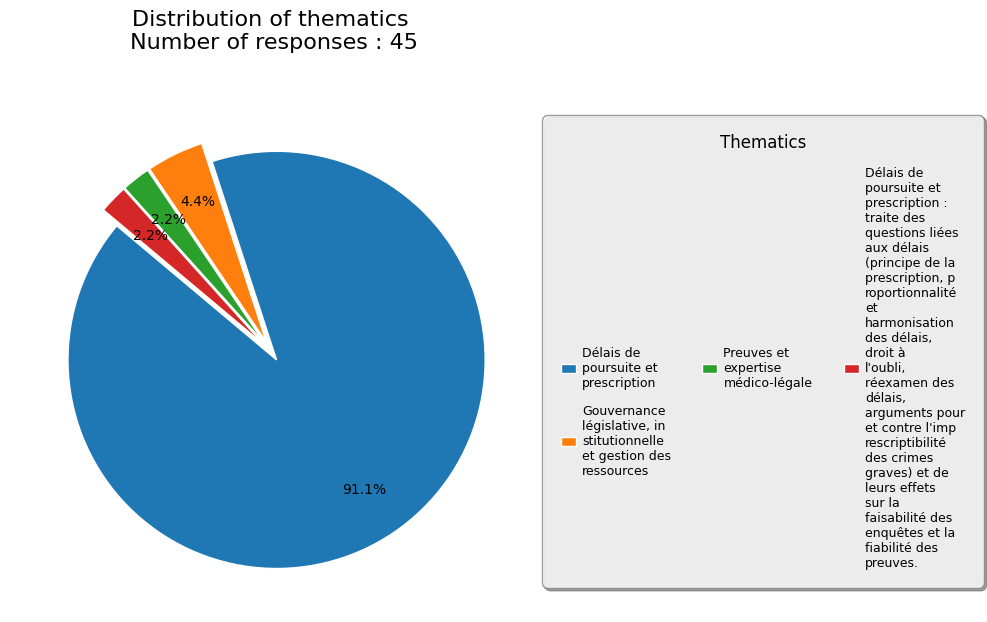

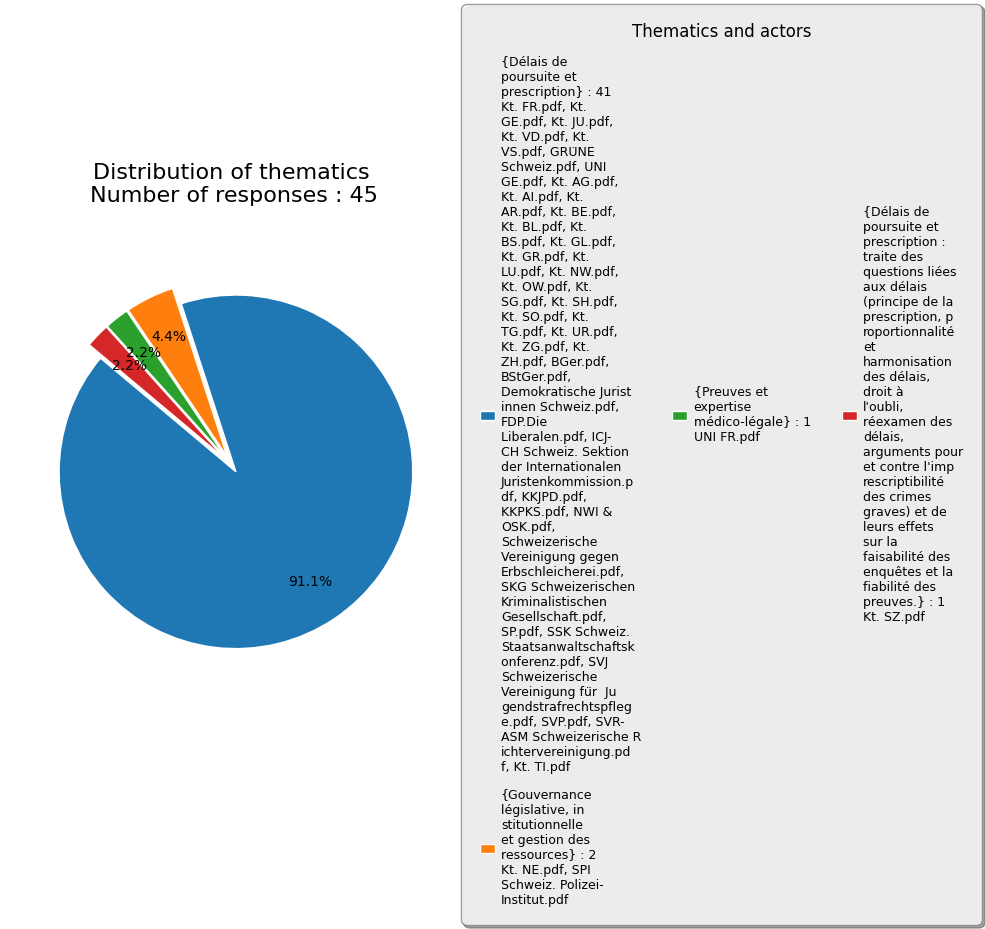

✅ Graphique enregistré dans : ./graphs/distribution_cleaned_themes_actors.pdf


In [ ]:


theme_col = 'category_fr'

df = df.dropna(subset=[theme_col])
themes = df[theme_col].tolist()

# Compute embeddings using a pretrained model
# Choice of embedding model: " sentence-transformers/distiluse-base-multilingual-cased-v1" For working with French
model = SentenceTransformer('distiluse-base-multilingual-cased-v1')
theme_embeddings = model.encode(themes)

# Calculate pairwise cosine similarity
similarity_matrix = cosine_similarity(theme_embeddings)

# Set diagonal to 0 to ignore self-similarity
np.fill_diagonal(similarity_matrix, 0)

# Merge themes based on similarity threshold
similarity_threshold_low = 0.80
similarity_threshold_high = 0.999

# Create a mapping for merged themes
theme_map = dict()

for idx, theme in enumerate(themes):
    if theme in theme_map:
        continue

    # Find indices where similarity is within threshold
    similar_idxs = np.where(
        (similarity_matrix[idx] >= similarity_threshold_low) &
        (similarity_matrix[idx] <= similarity_threshold_high)
    )[0]

    # Merge themes into the most frequent canonical theme
    candidates = [themes[i] for i in similar_idxs] + [theme]
    canonical = df[df[theme_col].isin(candidates)][theme_col].value_counts().idxmax()

    for candidate in candidates:
        theme_map[candidate] = canonical

# Apply merging
df['cleaned_theme'] = df[theme_col].map(theme_map)

# Recount theme frequencies after cleaning
cleaned_counts = df['cleaned_theme'].value_counts()

# --- Graph Styling (Themes Only) ---
fig, ax = plt.subplots(figsize=(10, 10))
explode = [0.05] * len(cleaned_counts)

wedges, texts, autotexts = ax.pie(
    cleaned_counts,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    pctdistance=0.75,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

ax.set(aspect="equal")
ax.set_title(
    f"Distribution of thematics\n Number of responses : {cleaned_counts.sum()}",
    fontsize=16,
    pad=30
)

legend_labels = ["\n".join(textwrap.wrap(cat, width=15)) for cat in cleaned_counts.index]

legend = ax.legend(
    wedges,
    legend_labels,
    title="Thematics",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=12,
    ncol=3,
    frameon=True,
    shadow=True,
    facecolor='white',
    framealpha=0.8,
    edgecolor='gray',
    borderpad=1,
    handlelength=1.2,
    handletextpad=0.5,
    columnspacing=2.5,
    labelspacing=1.2
)
legend.get_frame().set_boxstyle('round,pad=0.5')

plt.tight_layout()
plt.show()

# --- Second Graph (Themes with Actors) ---
actors_by_cat = df.groupby('cleaned_theme')['filename'].apply(list)

fig, ax = plt.subplots(figsize=(10, 10))

wedges, texts, autotexts = ax.pie(
    cleaned_counts,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    pctdistance=0.75,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

ax.set(aspect="equal")
ax.set_title(
    f"Distribution of thematics\n Number of responses : {cleaned_counts.sum()}",
    fontsize=16,
    pad=30
)

def wrap_label(cat):
    cat_wrapped = "\n".join(textwrap.wrap(cat, width=15))
    acteurs = actors_by_cat.get(cat, [])
    details_wrapped = "\n".join(textwrap.wrap(", ".join(acteurs), width=20))
    label = rf"{{{cat_wrapped}}} : {len(acteurs)}"
    if acteurs:
        label += "\n" + details_wrapped
    return label

legend_labels = [wrap_label(cat) for cat in cleaned_counts.index]

legend = ax.legend(
    wedges,
    legend_labels,
    title="Thematics and actors",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=12,
    ncol=3,
    frameon=True,
    shadow=True,
    facecolor='white',
    framealpha=0.8,
    edgecolor='gray',
    borderpad=1,
    handlelength=1.2,
    handletextpad=0.5,
    columnspacing=2.5,
    labelspacing=1.2
)
legend.get_frame().set_boxstyle('round,pad=0.5')

plt.tight_layout()
plt.show()

# Save the figure
output_dir = './graphs'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "distribution_cleaned_themes_actors.pdf")
fig.savefig(output_path, bbox_inches="tight")
plt.close()

print(f"✅ Graphique enregistré dans : {output_path}")



/tmp/ipython-input-1977812278.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(wrapped_labels)


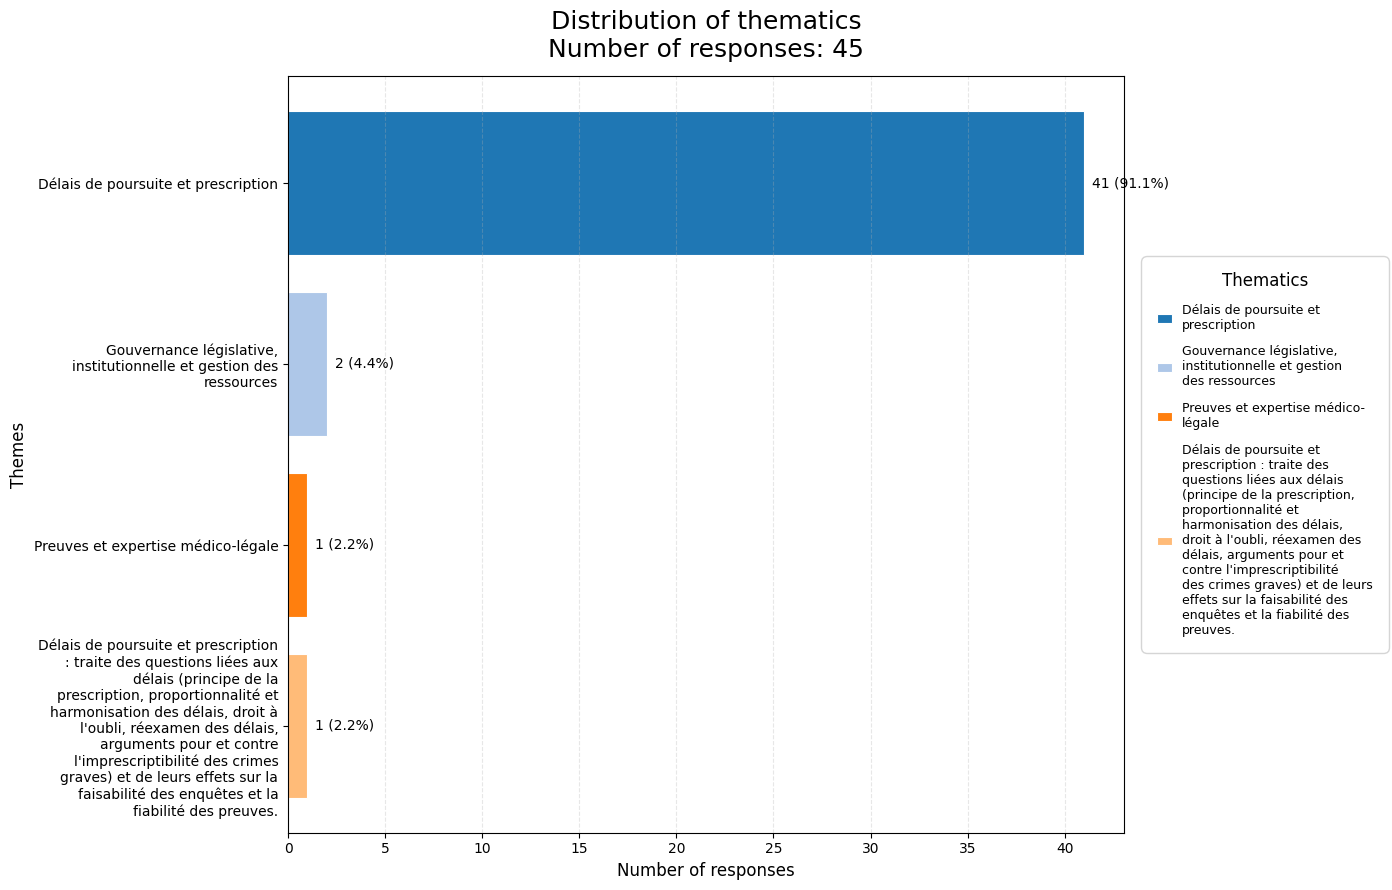

/tmp/ipython-input-1977812278.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(wrapped_ticks)
/tmp/ipython-input-1977812278.py:174: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


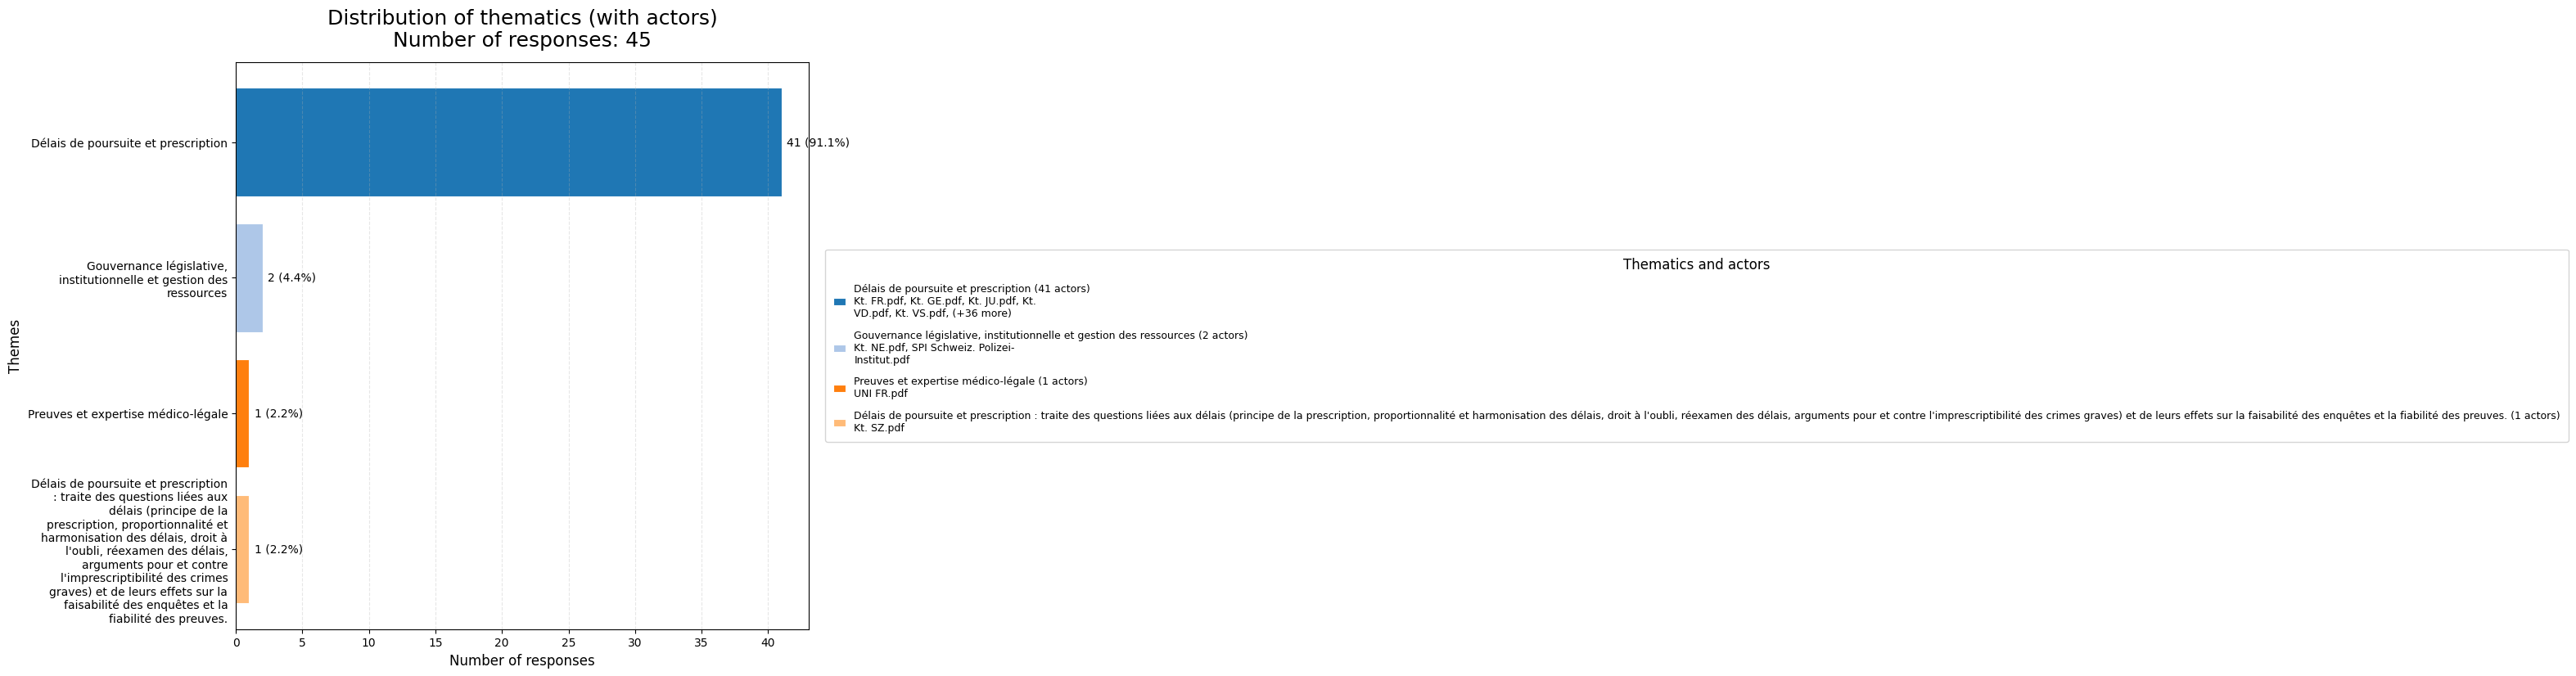

✅ Graphique enregistré dans : ./graphs/distribution_cleaned_themes_actors.pdf


In [ ]:
# --- Graph Styling (Themes Only) — improved readability ---
# Sort by descending frequency for consistent order
cleaned_counts = cleaned_counts.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 9))  # bigger, clearer figure

# Colors: tab20 palette cycling through if many themes
palette = list(plt.cm.tab20.colors)
colors = [palette[i % len(palette)] for i in range(len(cleaned_counts))]

# Horizontal bar chart
bars = ax.barh(
    cleaned_counts.index,
    cleaned_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

# Titles and labels
ax.set_xlabel("Number of responses", fontsize=12)
ax.set_ylabel("Themes", fontsize=12)
ax.set_title(
    f"Distribution of thematics\nNumber of responses: {cleaned_counts.sum()}",
    fontsize=18, pad=14
)

# Show most frequent on top
ax.invert_yaxis()

# Light horizontal gridlines
ax.xaxis.grid(True, linestyle='--', alpha=0.3)
ax.margins(x=0.05)

# Wrap long y-axis labels for readability
wrapped_labels = [textwrap.fill(label, width=35) for label in cleaned_counts.index]
ax.set_yticklabels(wrapped_labels)

# Annotate values and percentages
vals = cleaned_counts.values
pcts = vals / vals.sum() * 100
xpad = max(vals) * 0.01 if len(vals) else 0.5
for i, (v, p) in enumerate(zip(vals, pcts)):
    ax.text(v + xpad, i, f"{v} ({p:.1f}%)", va='center', fontsize=10)

# --- Legend styling ---------------------------------------------------------
legend_labels = [
    "\n".join(textwrap.wrap(cat, width=30)) for cat in cleaned_counts.index
]

legend = ax.legend(
    bars,
    legend_labels,
    title="Thematics",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=12,
    ncol=1,
    frameon=True,
    shadow=False,
    facecolor='white',
    framealpha=0.95,
    edgecolor='lightgray',
    borderpad=0.8,
    handlelength=1.2,
    handletextpad=0.8,
    labelspacing=1.1
)
legend.get_frame().set_boxstyle('round,pad=0.5')

# Adjust margins to give legend room
fig.subplots_adjust(left=0.25, right=0.75)

plt.tight_layout()
plt.show()




# Ensure cleaned_theme column exists and fill unmapped themes
if 'cleaned_theme' not in df.columns:
    df['cleaned_theme'] = df[theme_col]

# Fill missing values in cleaned_theme with original themes
df['cleaned_theme'] = df['cleaned_theme'].fillna(df[theme_col])


# --- Second Graph (Themes with Actors) — readable version ---
actors_by_cat = df.groupby('cleaned_theme')['filename'].apply(list).to_dict()

# Sort descending so the longest bar is on top
cleaned_counts = cleaned_counts.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 9))  # bigger canvas

# Colors: cycle through tab20 safely
palette = list(plt.cm.tab20.colors)
colors = [palette[i % len(palette)] for i in range(len(cleaned_counts))]

bars = ax.barh(
    cleaned_counts.index,
    cleaned_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

# Axes titles & labels
ax.set_xlabel("Number of responses", fontsize=12)
ax.set_ylabel("Themes", fontsize=12)
ax.set_title(
    f"Distribution of thematics (with actors)\nNumber of responses: {cleaned_counts.sum()}",
    fontsize=18, pad=14
)

# Put most frequent on top
ax.invert_yaxis()

# Light grid and a bit of padding
ax.xaxis.grid(True, which='major', linestyle='--', alpha=0.3)
ax.margins(x=0.05)

# Wrap long y-tick labels
wrapped_ticks = [textwrap.fill(cat, width=35) for cat in cleaned_counts.index]
ax.set_yticklabels(wrapped_ticks)

# Add values + % at the end of bars
vals = cleaned_counts.values
pcts = vals / vals.sum() * 100
xpad = (max(vals) * 0.01) if len(vals) else 0.5
for i, (v, p) in enumerate(zip(vals, pcts)):
    ax.text(v + xpad, i, f"{v} ({p:.1f}%)", va='center', fontsize=10)

# ---- Compact legend ---------------------------------------------------------
def compact_label(cat, max_names=5, wrap_width=42):
    names = actors_by_cat.get(cat, [])
    if not names:
        return f"{cat} (0 actors)\n—"
    shown = names[:max_names]
    remaining = len(names) - len(shown)
    base = ", ".join(shown)
    if remaining > 0:
        base += f", (+{remaining} more)"
    wrapped = "\n".join(textwrap.wrap(base, width=wrap_width))
    return f"{cat} ({len(names)} actors)\n{wrapped}"

legend_labels = [compact_label(cat) for cat in cleaned_counts.index]

# Use the bars as handles; place legend right, single column, smaller font
legend = ax.legend(
    bars,
    legend_labels,
    title="Thematics and actors",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=12,
    ncol=1,
    frameon=True,
    shadow=False,
    facecolor='white',
    framealpha=0.95,
    edgecolor='lightgray',
    borderpad=0.8,
    handlelength=1.2,
    handletextpad=0.8,
    labelspacing=1.1
)

# Extra room on left/right for labels & legend
fig.subplots_adjust(left=0.28, right=0.78)

plt.tight_layout()
plt.show()

# Save the figure
output_dir = './graphs'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "distribution_cleaned_themes_actors.pdf")
fig.savefig(output_path, bbox_inches="tight")
plt.close()

print(f"✅ Graphique enregistré dans : {output_path}")


In [ ]:

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)


output_excel = base_dir / "openai_outputs_with_thematics.xlsx"

file_map = {}
for lang, folder in roots.items():
    if not folder.exists():
        logger.warning(f"Dossier non trouvé: {folder}")
        file_map[lang] = {}
    else:
        lang_map = {}
        for p in folder.rglob("*.pdf"):
            name_norm = unicodedata.normalize("NFC", p.name)
            lang_map[name_norm] = p
        file_map[lang] = lang_map
        logger.info(f"{lang}: {len(lang_map)} fichiers PDF indexés")

if output_excel.exists():
    df = pd.read_excel(output_excel, engine="openpyxl")
    df.columns = df.columns.str.strip().str.lower()
    for col in ["lang", "filename", "volet1", "avis"]:
        if col not in df.columns:
            df[col] = None
    df.rename(columns={"avis": "Avis"}, inplace=True)
else:
    records = []
    for lang, files in file_map.items():
        for fname in files:
            records.append({"lang": lang, "filename": fname, "volet1": None, "Avis": None})
    df = pd.DataFrame(records)
    logger.info(f"DataFrame initialisé avec {len(df)} lignes")

templates_simple = {
    "FR": (
        "Tu es un haut-fonctionnaire chargé de produire un rapport de consultation sur une réforme du code pénal.\n"
        "Pour chaque avis d'acteur sur cet objet , indiquez si l'avis est positif, négatif ou neutre.\n"
        "Répond **UNIQUEMENT** par un seul mot parmi : « positif », « neutre » ou « négatif ».\n\n"
        "Objet :\n"
        "Ajouter l'assassinat à la liste des infractions imprescriptibles dans le code pénal et le code pénal militaire.\n\n"
        "Avis à analyser :\n{texte}"
    ),
    "DE": (
        "Du bist ein hoher Beamter, der beauftragt wurde, einen Konsultationsbericht über eine Reform des Strafgesetzbuches zu erstellen.\n"
        "Für jede Stellungnahme eines Akteurs zu diesem Gegenstand gib an, ob die Stellungnahme positiv, negativ oder neutral ist.\n"
        "Antworte **AUSSCHLIESSLICH** mit einem einzigen Wort: „positiv“, „neutral“ oder „negativ“.\n\n"
        "Gegenstand:\n"
        "Ergänzung des Mordes in die Liste der nicht verjährbaren Straftaten im Strafgesetzbuch und im Militärstrafgesetzbuch.\n\n"
        "Stellungnahme zur Analyse:\n"
        "{texte}"
    ),
    "IT": (
        "Sei un alto funzionario incaricato di redigere un rapporto di consultazione su una riforma del codice penale.\n"
        "Per ciascun parere di un attore su questo oggetto, indica se il parere è positivo, negativo o neutro.\n"
        "Rispondi **ESCLUSIVAMENTE** con una sola parola tra: “positivo”, “neutro” o “negativo”.\n\n"
        "Oggetto:\n"
        "Aggiungere l'omicidio all'elenco dei reati imprescrittibili nel codice penale e nel codice penale militare.\n\n"
        "Parere da analizzare:\n"
        "{texte}"
    ),
}

allowed_map = {
    "FR": {"positif", "neutre", "négatif"},
    "DE": {"positiv", "neutral", "negativ"},
    "IT": {"positivo", "neutro", "negativo"},
}
MAX_RETRIES = 3
SAVE_INTERVAL = 1


def extract_text(pdf_path: Path) -> str:
    reader = PdfReader(str(pdf_path))
    return "\n".join(page.extract_text() or "" for page in reader.pages)


for idx, row in df.iterrows():
    if pd.notna(row.get("volet1")):
        continue

    lang = row["lang"]
    fname = unicodedata.normalize("NFC", str(row["filename"]).strip())
    pdf_path = file_map.get(lang, {}).get(fname)
    if not pdf_path:
        logger.error(f"Fichier introuvable : {lang}/{fname}")
        continue

    logger.info(f"Traitement de {lang}/{fname} (index {idx})")
    full_text = extract_text(pdf_path)
    prompt = templates_simple[lang].format(texte=full_text)

    for attempt in range(1, MAX_RETRIES + 1):
        # --- OPENAI REPLACEMENT FOR OLLAMA ---
        try:
            response_obj = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": prompt}],
                temperature=TEMPERATURE   # <--- uses your global setting
            )
            resp = response_obj.choices[0].message.content.strip().lower()

        except Exception as e:
            logger.error(f"Erreur OpenAI sur tentative {attempt} : {e}")
            resp = ""  # treat as invalid
        # --------------------------------------

        print("\n=== PROMPT ENVOYÉ ===")
        print(prompt)
        print("=== RÉPONSE DU MODÈLE ===")
        print(resp)

        if resp in allowed_map[lang]:
            df.at[idx, "volet1"] = resp
            df.at[idx, "Avis"] = resp
            logger.info(f"Réponse valide au tour {attempt} : {resp}")
            break
        else:
            logger.warning(f"Tentative {attempt} invalide : «{resp}»")
            df.at[idx, "volet1"] = None
            df.at[idx, "Avis"] = None
    else:
        logger.error(f"Échec après {MAX_RETRIES} essais pour l’index {idx}")

    if idx % SAVE_INTERVAL == 0 and idx > 0:
        try:
            df.to_excel(output_excel, index=False, engine="openpyxl")
            logger.info(f"Sauvegarde intermédiaire à l’index {idx}")
        except Exception as e:
            logger.error(f"Erreur lors de la sauvegarde intermédiaire : {e}")

try:
    df.to_excel(output_excel, index=False, engine="openpyxl")
    logger.info(f"Fichier sauvegardé : {output_excel}")
except Exception as e:
    logger.error(f"Erreur lors de l'écriture du fichier final : {e}")

print("✅ Traitement terminé.")


=== PROMPT ENVOYÉ ===
Tu es un haut-fonctionnaire chargé de produire un rapport de consultation sur une réforme du code pénal.
Pour chaque avis d'acteur sur cet objet , indiquez si l'avis est positif, négatif ou neutre.
Répond **UNIQUEMENT** par un seul mot parmi : « positif », « neutre » ou « négatif ».

Objet :
Ajouter l'assassinat à la liste des infractions imprescriptibles dans le code pénal et le code pénal militaire.

Avis à analyser :
Conseil  d’Etat  CE
Staatsrat  SR
Route  des  Arsenaux  41, 1700  Fribourg
ETAT  DE FRIBOURG
STAAT  FREIBURG  T +41  26 305  10 40
www.fr.ch/ce
Conseil  d’Etat
Route  des  Arsenaux  41, 1700  Fribourg
PAR  COURRIEL
Conseil  des Etats
Commission  des affaires  juridiques
3003  Berne
Courriel  : info.strafrecht@bj.admin.ch
Fribourg,  le 26 mars  2024
2024-321
Avant-projet  de loi fédérale  sur  l’imprescriptibilité  de ’assassinat
Monsieur  le Président,
Par courrier  du 9 janvier  2024,  vous  nous  avez  consultés  sur l’objet  cité en titre,  et 

In [ ]:


translation_map = {
    "positiv":  "positif",
    "negativ":  "négatif",
    "neutral":  "neutre",
    "positiva": "positif",
    "positivo": "positif",
    "negativo": "négatif",
    "neutrale": "neutre",
    "positif":  "positif",
    "negatif":  "négatif",
    "neutre":   "neutre"
}


df['volet1_norm'] = df['volet1'].str.strip().str.lower()

df['volet1_fr'] = df['volet1_norm'].map(translation_map).fillna(df['volet1'])

df.drop(columns=['volet1_norm'], inplace=True)

print(df[['filename','volet1','volet1_fr']].head())

df.to_excel(input_excel, index=False)

     filename   volet1 volet1_fr
0  Kt. FR.pdf  négatif   négatif
1  Kt. GE.pdf  négatif   négatif
2  Kt. JU.pdf  positif   positif
3  Kt. NE.pdf   neutre    neutre
4  Kt. VD.pdf  négatif   négatif


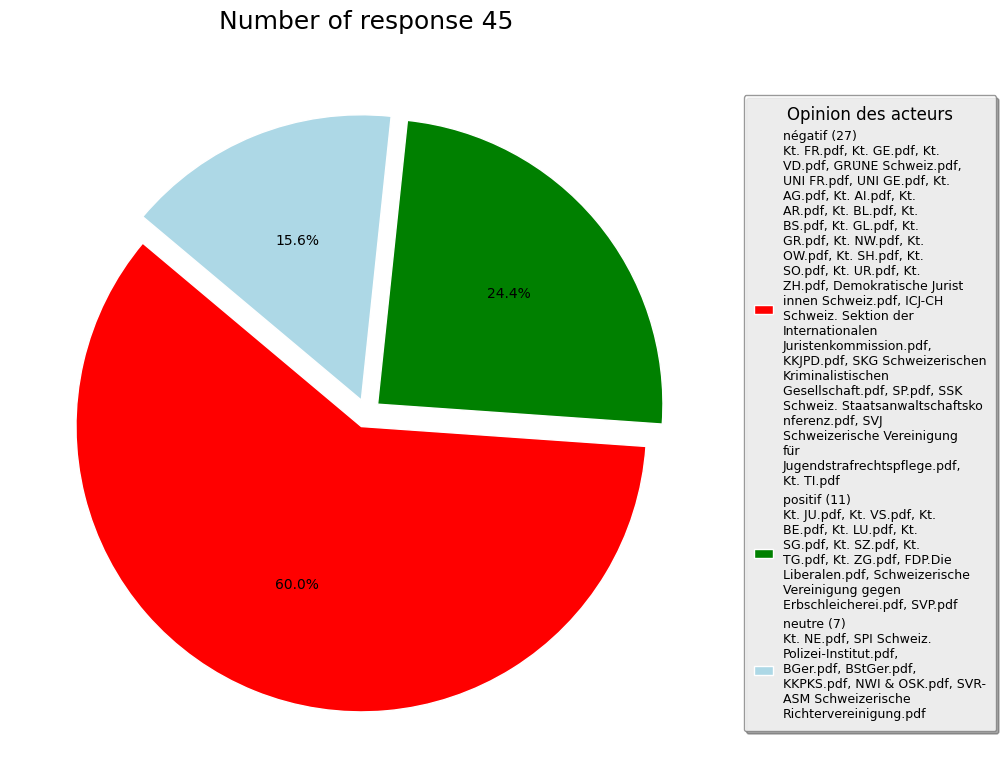

✅ Graphiques enregistrés dans : /content/drive/MyDrive/Consulation_NLP_imp/Graph


In [ ]:

output_dir = '/content/drive/MyDrive/Consulation_NLP_imp/Graph'
os.makedirs(output_dir, exist_ok=True)

for volet in ['volet1_fr']:
    counts = df[volet].value_counts()
    actors_by_cat = df.groupby(volet)['filename'].apply(list)
    total = counts.sum()

    fig, ax = plt.subplots(figsize=(12, 8))

    color_map = {'négatif': 'red', 'positif': 'green', 'neutre': 'lightblue'}
    colors = [color_map.get(c, 'gray') for c in counts.index]
    explode = [0.05] * len(counts)

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=None,
        autopct=lambda pct: f"{pct:.1f}%",
        pctdistance=0.6,
        startangle=140,
        explode=explode,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
        colors=colors
    )
    ax.set(aspect="equal")
    ax.set_title(f"Number of response {total}", fontsize=18, pad=20)

    legend_labels = []
    for cat in counts.index:
        n = counts[cat]
        detail = ", ".join(actors_by_cat[cat])
        wrapped = textwrap.fill(detail, width=30)
        legend_labels.append(f"{cat} ({n})\n{wrapped}")
    ax.legend(
        wedges,
        legend_labels,
        title="Opinion des acteurs",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        title_fontsize=12,
        frameon=True,
        shadow=True,
        facecolor='white',
        framealpha=0.8,
        edgecolor='gray',
        handlelength=1.5,
        borderpad=0.8
    )

    plt.tight_layout()
    plt.show()
    output_path = os.path.join(output_dir, f"repartition_{volet}.pdf")
    fig.savefig(output_path, bbox_inches='tight')
    plt.close()

print(f"✅ Graphiques enregistrés dans : {output_dir}")


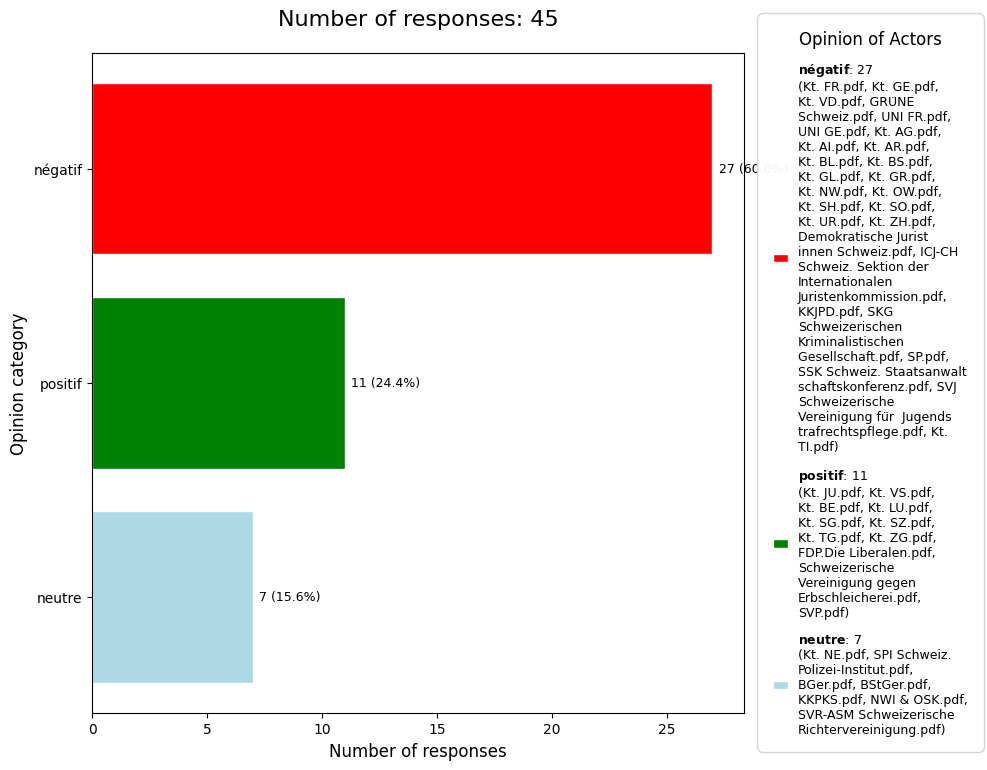

✅ Graphiques enregistrés dans : /content/drive/MyDrive/Consulation_NLP_imp/Graph


In [ ]:
for volet in ['volet1_fr']:
    counts = df[volet].dropna().value_counts()
    actors_by_cat = df.dropna(subset=[volet]).groupby(volet)['filename'].apply(list)
    total_responses = counts.sum()

    # 2) Création de la figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # --- Définition des couleurs par catégorie
    color_map = {
        'négatif': 'red',
        'positif': 'green',
        'neutre': 'lightblue'
    }
    default_color = 'gray'
    colors = [color_map.get(cat, default_color) for cat in counts.index]

    # 3) Tracé du bar chart horizontal
    bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1)

    # 4) Titre et labels
    ax.set_xlabel("Number of responses", fontsize=12)
    ax.set_ylabel("Opinion category", fontsize=12)
    ax.set_title(f"Number of responses: {total_responses}", fontsize=16, pad=20)

    # Inverser l’ordre pour que la catégorie la plus fréquente soit en haut
    ax.invert_yaxis()

    # Afficher valeurs + pourcentages au bout des barres
    vals = counts.values
    pcts = (vals / total_responses) * 100
    xpad = max(vals) * 0.01 if len(vals) else 0.5
    for i, (v, p) in enumerate(zip(vals, pcts)):
        ax.text(v + xpad, i, f"{v} ({p:.1f}%)", va='center', fontsize=9)

    # 5) Wrapping + mise en gras de la catégorie pour la légende
    def wrap_label(cat):
        details = ", ".join(actors_by_cat.get(cat, []))
        wrapped = "\n".join(textwrap.wrap(details, width=25)) if details else "No actors listed"
        return (
            rf"$\mathbf{{{cat}}}$: {len(actors_by_cat.get(cat, []))}"
            + "\n(" + wrapped + ")"
        )

    legend_labels = [wrap_label(cat) for cat in counts.index]



    # 6) Légende stylée (3 colonnes, shadow=True)

    legend = ax.legend(
        bars,
        legend_labels,
        title="Opinion of Actors",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        title_fontsize=12,
        ncol=1,
        frameon=True,
        shadow=False,
        facecolor='white',
        framealpha=0.95,
        edgecolor='lightgray',
        borderpad=0.8,
        handlelength=1.2,
        handletextpad=0.8,
        labelspacing=1.1
    )
    legend.get_frame().set_boxstyle('round,pad=0.5')

    plt.tight_layout()
    plt.show()

    # 7) Sauvegarde
    output_path = os.path.join(output_dir, f"repartition_{volet}.pdf")
    fig.savefig(output_path, bbox_inches='tight')
    plt.close()

print(f"✅ Graphiques enregistrés dans : {output_dir}")

We are now trying to develop a prompt that will allow you to see the proposed modifications made by the various stakeholders.

In [ ]:

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

templates = {
    "FR": {
        "Amendement": (
            "Tu es un haut-fonctionnaire mandaté pour produire un rapport sur la réforme du "
            "code pénal en Suisse.\n"
            "Tu recevras **un avis de partie prenante à la fois**. Pour chaque avis, fais :\n"
            "1. **Extrais uniquement les propositions de modification** sous forme de liste à puces.\n"
            "2. Pour chaque proposition : reformulation concise, catégorie, référence précise.\n"
            "3. **Pas d'autre commentaire**.\n\n"
            "**Texte :** {texte}"
        )
    },
    "DE": {
        "Amendement": (
            """\
Du bist ein hoher Beamter, der beauftragt wurde, einen Bericht über die Reform des Strafgesetzbuches in der Schweiz zu erstellen.
Du wirst **jeweils nur eine Stellungnahme von Stakeholdern** erhalten. Für jede Stellungnahme führe Folgendes aus:

1. **Extrahiere ausschließlich die Änderungsvorschläge** und gib sie als Aufzählungsliste wieder.
2. Für jeden Vorschlag:
   - prägnante Umformulierung
   - Kategorie
   - genaue Referenz
3. **Keinen weiteren Kommentar**.

**Text:** {texte}"""
        )
    },
    "IT": {
        "Amendement": (
            """\
Sei un alto funzionario incaricato di redigere un rapporto sulla riforma del codice penale in Svizzera.
Riceverai **un parere di stakeholder alla volta**. Per ciascun parere esegui:

1. **Estrai esclusivamente le proposte di modifica** e riportale come elenco puntato.
2. Per ogni proposta:
   - riformulazione concisa
   - categoria
   - riferimento preciso
3. **Nessun altro commento**.

**Testo:** {texte}"""
        )
    },
}


if output_excel.exists():
    try:
        df_existing = pd.read_excel(output_excel)
        logger.info("Loaded existing results from %s", output_excel)
    except Exception as e:
        logger.error("Failed to read existing Excel: %s", e)
        df_existing = pd.DataFrame(columns=["filename", "Amendement"])
else:
    df_existing = pd.DataFrame(columns=["filename", "Amendement"])

def extract_text_from_pdf(path: Path) -> str:
    """Lit et concatène le texte de chaque page du PDF."""
    try:
        reader = PdfReader(str(path))
        texts = [page.extract_text() or "" for page in reader.pages]
        full = "\n".join(texts)
        return full
    except Exception as e:
        logger.warning("Erreur lors de l'extraction de texte pour %s: %s", path, e)
        return ""

print("\n=== PROMPT ENVOYÉ ===")
print(prompt)
def call_llm(prompt: str) -> str:
    """Appel à l'LLM OpenAI et retourne la sortie."""
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE   # <-- your global temperature
        )
        result = response_obj.choices[0].message.content.strip()
        print("=== RÉPONSE DU MODÈLE ===")
        print(result)
        return result

    except Exception as e:
        logger.error("LLM call failed: %s", e)
        return ""


amend_dict = {}
for lang, folder in roots.items():
    if lang not in templates:
        logger.warning("No template for language %s, skipping", lang)
        continue
    tpl = templates[lang]["Amendement"]
    for pdf_path in folder.rglob("*.pdf"):
        logger.info("Processing %s", pdf_path.name)
        text = extract_text_from_pdf(pdf_path)
        if not text.strip():
            logger.warning("No text extracted for %s, skipping LLM", pdf_path.name)
            amend_dict[pdf_path.name] = ""
            continue
        prompt = tpl.format(texte=full_text)
        result = call_llm(prompt)
        amend_dict[pdf_path.name] = result

if not df_existing.empty:
    df_existing.set_index("filename", inplace=True)
    df_existing["Amendement"] = pd.Series(amend_dict)
    df_final = df_existing.reset_index()
else:
    df_final = pd.DataFrame(
        [{"filename": fname, "Amendement": a} for fname, a in amend_dict.items()]
    )

try:
    df_final.to_excel(output_excel, index=False)
    logger.info("Results saved to %s", output_excel)
except Exception as e:
    logger.error("Failed to write Excel: %s", e)

print(df_final.head())



=== PROMPT ENVOYÉ ===
Sei un alto funzionario incaricato di redigere un rapporto di consultazione su una riforma del codice penale.
Per ciascun parere di un attore su questo oggetto, indica se il parere è positivo, negativo o neutro.
Rispondi **ESCLUSIVAMENTE** con una sola parola tra: “positivo”, “neutro” o “negativo”.

Oggetto:
Aggiungere l'omicidio all'elenco dei reati imprescrittibili nel codice penale e nel codice penale militare.

Parere da analizzare:
Bellinzona
sl 0 20 marzo  2024Numero
1415
Consiglio  di Stato
Piazza  Governo  6
Casella  postale  2170
6501  Bellinzona
telefono  +41  91 814  41 11
+ ,oe canich  Repubblica  e Cantone
webwwwtich  Ticino
ll Consiglio  di Stato
Consiglio  degli  Stati
Commissione  degli  affari  giuridici
3003  Berna
Invio  per  posta  elettronica  (word  e pdf):
info.  strafrecht@bj.admin.ch
Procedura  di consultazione  relativa  alla  modifica  del Codice  penale  e del Codice
penale  militare  (Nessun  termine  di prescrizione  per  chi ha comm

To finalize our analysis, we will ask our model for a general opinion on the whole consultation process, using the summaries produced.

In [ ]:

translate_template = (
    "Veuillez traduire en français ce court texte en veillant à ce que le contenu soit clair et précis :\n\n"
    "{summary}\n\n"
    "**Réponds** sans en-tête, sans guillemets, sans autre texte."
    "texte en français :"
)


def translate_thematics(text):
    if not text.strip():
        return ""

    prompt = translate_template.format(summary=text)
    print("\n=== PROMPT ENVOYÉ ===")
    print(prompt)

    # --- OPENAI CALL (replacing ollama) ---
    try:
        response_obj = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE      # ← global variable you set at the top
        )
        response = response_obj.choices[0].message.content.strip()

    except Exception as e:
        print(f"⚠️ Échec pour «{text[:30]}…»\n{e}")
        return ""
    # --------------------------------------

    print("=== RÉPONSE DU MODÈLE ===")
    print(response)

    return response

df['summary_fr'] = df['summary'].astype(str).apply(translate_thematics)

df.to_excel(output_excel, index=False)
print("✅ Colonnes traduites ajoutées et fichier enregistré dans :", output_excel)


=== PROMPT ENVOYÉ ===
Veuillez traduire en français ce court texte en veillant à ce que le contenu soit clair et précis :

Le Conseil d’État de Fribourg, saisi en consultation le 9 janvier 2024 au sujet de l’avant‑projet de loi sur l’imprescriptibilité de l’assassinat, estime le projet inabouti pour les motifs suivants.

1) Preuves scientifiques insuffisantes seules
- Les progrès scientifiques (notamment l’ADN) plaident en faveur de l’imprescriptibilité, mais ces éléments matériels ne suffisent pas à établir, à eux seuls, le crime qualifié d’assassinat au sens de l’art. 112 CP.  
- Une condamnation pour assassinat requiert aussi d’autres éléments (notamment l’audition de témoins) pour démontrer l’« absence particulière de scrupules ». Avec l’écoulement du temps, les témoignages risquent d’être peu fiables ou fallacieux, et donc d’accroître le risque d’erreurs judiciaires.

2) Problèmes liés aux délais de prescription actuels
- Le code pénal prévoit déjà une prescription de 15 ans pour

In [ ]:

df.columns = df.columns.str.strip()

col_name = 'summary_fr'
if col_name not in df.columns:
    raise KeyError(f"La colonne '{col_name}' n’existe pas.")

texts = (
    df[col_name]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s != ""]
    .tolist()
)
if not texts:
    raise ValueError(f"Aucun résumé trouvé dans '{col_name}'")

numbered = "\n".join(f"{i+1}. {t}" for i, t in enumerate(texts, 1))

# --- Construction du prompt
prompt = f"""\
Tu es un haut fonctionnaire chargé de produire un rapport synthétique sur une consultation concernant une réforme de la franchise d’impôt à l’importation de biens en petites quantités en Suisse.

Tu vas recevoir ci-dessous une liste numérotée contenant les résumés individuels des avis exprimés par chacune des parties prenantes concernant le sujet de consultation suivant :
« {col_name} »

{numbered}

Sur la base de ces résumés individuels, ta tâche consiste à produire une synthèse très succincte de l'opinion générale des parties prenantes sur le sujet, en suivant ces consignes strictes :

    1) Identifie une unique catégorie exprimant la tendance générale dominante parmi les avis (ex. consensus positif, consensus négatif, division, réserve générale, soutien conditionnel, etc.).
    2) Rédige une description concise explicitant clairement et précisément cette position générale, en mettant en évidence les points majeurs d'accord ou de désaccord mentionnés fréquemment par les parties prenantes.

Réponds sans en-tête, sans guillemets.
"""
print("=== PROMPT ENVOYÉ ===\n", prompt)

# --- OPENAI CALL replacing ollama ---
try:
    response_obj = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": prompt}],
        temperature=TEMPERATURE      # ← global variable you defined
    )
    response = response_obj.choices[0].message.content.strip()

except Exception as e:
    raise RuntimeError(f"OpenAI erreur :\n{e}")
# ------------------------------------

print("=== RÉPONSE DU MODÈLE ===\n", response)


if 'Global_Summary' in df.columns:
    df = df.drop(columns=['Global_Summary'])

insert_at = df.columns.get_loc(col_name) + 1
df.insert(insert_at, 'Global_Summary', "")
df.iat[0, insert_at] = response

df.to_excel(input_excel, index=False)
print("✅ Colonne 'Global_Summary' ajoutée, réponse insérée en ligne 1.")


=== PROMPT ENVOYÉ ===
 Tu es un haut fonctionnaire chargé de produire un rapport synthétique sur une consultation concernant une réforme de la franchise d’impôt à l’importation de biens en petites quantités en Suisse.

Tu vas recevoir ci-dessous une liste numérotée contenant les résumés individuels des avis exprimés par chacune des parties prenantes concernant le sujet de consultation suivant :
« summary_fr »

2. Le Conseil d’État du canton de Fribourg, consulté le 9 janvier 2024 sur l’avant-projet de loi relatif à l’imprescriptibilité de l’assassinat, juge le projet inabouti pour les motifs suivants.

1) Preuves scientifiques insuffisantes
- Les progrès scientifiques (notamment l’analyse ADN) plaident en faveur de l’imprescriptibilité, mais ces preuves matérielles ne suffisent pas, à elles seules, à caractériser l’assassinat au sens de l’art. 112 CP.
- Une condamnation pour assassinat exige en outre d’autres éléments (notamment l’audition de témoins) permettant d’établir l’absence par

In [ ]:

col_name = 'summary_fr'
if col_name not in df.columns:
    raise KeyError(f"La colonne '{col_name}' n’existe pas.")

texts = (
    df[col_name]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s != ""]
    .tolist()
)
if not texts:
    raise ValueError(f"Aucun résumé trouvé dans '{col_name}'")

numbered = "\n".join(f"{i+1}. {t}" for i, t in enumerate(texts, 1))

prompt = f"""\
Tu es un haut fonctionnaire chargé de produire un rapport synthétique sur une consultation concernant une réforme de la franchise d’impôt à l’importation de biens en petites quantités en Suisse.

Tu vas recevoir ci-dessous une liste numérotée contenant les résumés individuels des avis exprimés par chacune des parties prenantes concernant le sujet de consultation suivant :
« {col_name} »

{numbered}

Sur la base de ces résumés individuels, ta tâche consiste à produire une synthèse des justifications principales des parties prenantes sur le sujet, il faut que tu donnes les grandes raisons pourquoi les acteurs sont contre ou pour la réforme , formule ta réponse sous la forme d'une liste a puce.

Réponds sans en-tête, sans guillemets.
"""
print("=== PROMPT ENVOYÉ ===\n", prompt)

# --- OPENAI CALL replacing Ollama ---
try:
    response_obj = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": prompt}],
        temperature=TEMPERATURE       # <--- your global temperature variable
    )
    response = response_obj.choices[0].message.content.strip()

except Exception as e:
    raise RuntimeError(f"OpenAI erreur :\n{e}")
# ------------------------------------

print("=== RÉPONSE DU MODÈLE ===\n", response)


if 'Position_Summary' in df.columns:
    df = df.drop(columns=['Position_Summary'])

insert_at = df.columns.get_loc(col_name) + 1
df.insert(insert_at, 'Position_Summary', "")
df.iat[0, insert_at] = response

df.to_excel(input_excel, index=False)
print("✅ Colonne 'Position_Summary' ajoutée, réponse insérée en ligne 1.")


=== PROMPT ENVOYÉ ===
 Tu es un haut fonctionnaire chargé de produire un rapport synthétique sur une consultation concernant une réforme de la franchise d’impôt à l’importation de biens en petites quantités en Suisse.

Tu vas recevoir ci-dessous une liste numérotée contenant les résumés individuels des avis exprimés par chacune des parties prenantes concernant le sujet de consultation suivant :
« summary_fr »

2. Le Conseil d’État du canton de Fribourg, consulté le 9 janvier 2024 sur l’avant-projet de loi relatif à l’imprescriptibilité de l’assassinat, juge le projet inabouti pour les motifs suivants.

1) Preuves scientifiques insuffisantes
- Les progrès scientifiques (notamment l’analyse ADN) plaident en faveur de l’imprescriptibilité, mais ces preuves matérielles ne suffisent pas, à elles seules, à caractériser l’assassinat au sens de l’art. 112 CP.
- Une condamnation pour assassinat exige en outre d’autres éléments (notamment l’audition de témoins) permettant d’établir l’absence par